# Feature Engineering — Bot Detection

## Цель

Построить признаки поведения `cookie_id` на основе событий,
попадающих в заданное суточное окно наблюдения, и исследовать их
влияние на качество классификации ботов.

Основная метрика:

**Precision при Recall ≥ 70% (P@R≥0.70)**.

Дополнительные диагностические метрики:

- PR-AUC;
- ROC-AUC.

## Правила экспериментов

1. Все признаки строятся только по событиям внутри
   `[window_start_ts, window_end_ts)`.
2. `cookie_id` не используется как признак.
3. Данные `test` не используются для выбора признаков или моделей.
4. Разбиение выполняется по времени.
5. Для сравнения экспериментов используется один и тот же
   validation protocol.
6. Случайность фиксируется через `random_state`.
7. Официальная функция `precision_at_recall` из `metric.py`
   не изменяется.
8. Дубликаты событий на данном этапе не удаляются.
9. Признаки строятся на уровне `cookie_id`, поскольку метрика
   рассчитывается также на уровне `cookie_id`.

## Исследовательская стратегия

Признаки добавляются группами:

1. активность;
2. распределение типов событий;
3. временное поведение;
4. разнообразие контента;
5. User-Agent и platform;
6. поисковое поведение;
7. pointer-поведение;
8. последовательности событий.

Каждая группа оценивается отдельно и затем в составе накопительной
модели.

### 1. Импорты

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score


SEED = 42

ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR / "data"

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
EVENTS_PATH = DATA_DIR / "events.csv.gz"

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from metric import precision_at_recall


pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)

### 2. Загрузка данных

In [2]:
train = pd.read_csv(
    TRAIN_PATH,
    parse_dates=[
        "cookie_created_at",
        "window_start_ts",
        "window_end_ts",
    ],
)

test = pd.read_csv(
    TEST_PATH,
    parse_dates=[
        "cookie_created_at",
        "window_start_ts",
        "window_end_ts",
    ],
)

events = pd.read_csv(
    EVENTS_PATH,
    parse_dates=["event_ts"],
)

print(f"train:  {train.shape}")
print(f"test:   {test.shape}")
print(f"events: {events.shape}")

train:  (11091, 5)
test:   (4909, 4)
events: (328905, 14)


### 3. Базовые проверки

In [3]:
assert train["cookie_id"].is_unique
assert test["cookie_id"].is_unique

assert not set(train["cookie_id"]) & set(test["cookie_id"])

assert train["target"].isin([0, 1]).all()

assert (
    train["window_end_ts"] - train["window_start_ts"]
).eq(pd.Timedelta(days=1)).all()

assert (
    test["window_end_ts"] - test["window_start_ts"]
).eq(pd.Timedelta(days=1)).all()

print("Basic data checks: OK")

Basic data checks: OK


### 4. Формируем события внутри окна

In [4]:
def events_in_window(
    events: pd.DataFrame,
    meta: pd.DataFrame,
) -> pd.DataFrame:
    meta_window = meta[
        [
            "cookie_id",
            "window_start_ts",
            "window_end_ts",
        ]
    ]

    ev = events.merge(
        meta_window,
        on="cookie_id",
        how="inner",
        validate="many_to_one",
    )

    mask = (
        (ev["event_ts"] >= ev["window_start_ts"])
        & (ev["event_ts"] < ev["window_end_ts"])
    )

    ev = ev.loc[mask].copy()

    return ev

In [5]:
ev_train = events_in_window(events, train)
ev_test = events_in_window(events, test)

print("Train events in window:", len(ev_train))
print("Test events in window:", len(ev_test))

Train events in window: 198436
Test events in window: 89690


### 5. Сортировка событий

In [6]:
ev_train = (
    ev_train
    .sort_values(
        ["cookie_id", "event_ts", "eid"],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

ev_test = (
    ev_test
    .sort_values(
        ["cookie_id", "event_ts", "eid"],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

print("Train sorted:", ev_train[["cookie_id", "event_ts"]].head())
print("Test sorted:", ev_test[["cookie_id", "event_ts"]].head())

Train sorted:              cookie_id            event_ts
0  ck_000c95f1408dcb00 2026-04-19 14:49:54
1  ck_000c95f1408dcb00 2026-04-19 14:50:17
2  ck_000c95f1408dcb00 2026-04-19 15:50:21
3  ck_000c95f1408dcb00 2026-04-19 15:50:47
4  ck_000c95f1408dcb00 2026-04-19 15:51:45
Test sorted:              cookie_id            event_ts
0  ck_00013fdfa0bd37dd 2026-04-24 18:41:16
1  ck_00013fdfa0bd37dd 2026-04-24 19:16:53
2  ck_00013fdfa0bd37dd 2026-04-24 19:16:54
3  ck_00013fdfa0bd37dd 2026-04-24 19:17:05
4  ck_00013fdfa0bd37dd 2026-04-24 20:05:05


### 6. Нормализация platform

In [7]:
for df in (ev_train, ev_test):
    df["platform_normalized"] = (
        df["platform"]
        .str.strip()
        .str.lower()
    )

print(ev_train["platform_normalized"].value_counts())

platform_normalized
web        82152
android    77991
desktop    27855
ios         7836
iphone      2602
Name: count, dtype: int64


### 7. Cookie metadata

In [8]:
def add_metadata_features(meta: pd.DataFrame) -> pd.DataFrame:
    result = meta[
        ["cookie_id", "cookie_created_at", "window_start_ts", "window_end_ts"]
    ].copy()

    result["cookie_age_seconds"] = (
        result["window_start_ts"] - result["cookie_created_at"]
    ).dt.total_seconds()

    result["cookie_age_hours"] = (
        result["cookie_age_seconds"] / 3600
    )

    return result

In [9]:
meta_train = add_metadata_features(train)
meta_test = add_metadata_features(test)

meta_train[["cookie_id", "cookie_age_hours"]].head()

,cookie_id,cookie_age_hours
0,ck_54a059eb7d3ea68b,3254.488611
1,ck_7e4de46eeab82974,4669.826667
2,ck_9320229ef6304522,791.866111
3,ck_30ccd25bc1714ed9,13.122222
4,ck_a77c5f05948cdeef,2276.090278


### 8. Activity

In [10]:
def build_activity_features(ev: pd.DataFrame) -> pd.DataFrame:
    g = ev.groupby("cookie_id", sort=False)

    features = pd.DataFrame({
        "n_events": g.size(),

        "n_unique_items": g["item_id"].nunique(),

        "n_unique_categories": g["item_category"].nunique(),

        "n_unique_locations": g["item_location"].nunique(),

        "n_unique_search_queries": g["search_query"].nunique(),

        "n_unique_event_types": g["event_name"].nunique(),

        "n_unique_platforms": g["platform_normalized"].nunique(),

    })

    return features.reset_index()

In [11]:
activity_train = build_activity_features(ev_train)
activity_test = build_activity_features(ev_test)

print("Train:", activity_train.shape)
print("Test:", activity_test.shape)

display(activity_train.head())

Train: (11091, 8)
Test: (4909, 8)


,cookie_id,n_events,n_unique_items,n_unique_categories,n_unique_locations,n_unique_search_queries,n_unique_event_types,n_unique_platforms
0,ck_000c95f1408dcb00,16,9,2,8,3,4,2
1,ck_000e8c52636e3bec,34,20,4,12,8,7,2
2,ck_0010e31baa4a1fb7,16,8,3,4,4,6,2
3,ck_0010ec3874fb5378,74,31,2,19,8,6,2
4,ck_001722063b94cae0,15,8,3,9,4,4,1


In [12]:
assert set(activity_train["cookie_id"]) == set(train["cookie_id"])
assert set(activity_test["cookie_id"]) == set(test["cookie_id"])

assert activity_train["cookie_id"].is_unique
assert activity_test["cookie_id"].is_unique

print("Activity feature coverage: OK")

Activity feature coverage: OK


### 9. Feature table

In [13]:
X_activity_train = (
    meta_train
    .merge(
        activity_train,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
)

X_activity_test = (
    meta_test
    .merge(
        activity_test,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
)

X_activity_train.shape, X_activity_test.shape

((11091, 13), (4909, 13))

In [14]:
X_activity_train = X_activity_train.merge(
    train[["cookie_id", "target"]],
    on="cookie_id",
    how="left",
    validate="one_to_one",
)

assert X_activity_train["target"].notna().all()

### 10. Фиксируем validation split

In [15]:
VALID_START = pd.Timestamp("2026-04-17")

is_valid = (
    train["window_start_ts"] >= VALID_START
)

print("Train rows:", (~is_valid).sum())
print("Validation rows:", is_valid.sum())

print("\nTrain positive rate:")
print(train.loc[~is_valid, "target"].mean())

print("\nValidation positive rate:")
print(train.loc[is_valid, "target"].mean())

Train rows: 9140
Validation rows: 1951

Train positive rate:
0.08085339168490153

Validation positive rate:
0.08200922603792926


### 11. Универсальная функция оценки

In [16]:
def evaluate_scores(
    y_true: pd.Series,
    scores: np.ndarray,
) -> dict:
    return {
        "P@R>=0.70": precision_at_recall(
            y_true.to_numpy(),
            scores,
            recall=0.70,
        ),
        "PR-AUC": average_precision_score(
            y_true,
            scores,
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            scores,
        ),
    }

In [17]:
def fit_evaluate_rf(
    X: pd.DataFrame,
    feature_cols: list[str],
    train_mask: pd.Series,
    valid_mask: pd.Series,
    y: pd.Series,
    random_state: int = 0,
):
    model = RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        random_state=random_state,
        n_jobs=-1,
    )

    model.fit(
        X.loc[train_mask, feature_cols],
        y.loc[train_mask],
    )

    valid_scores = model.predict_proba(
        X.loc[valid_mask, feature_cols]
    )[:, 1]

    metrics = evaluate_scores(
        y.loc[valid_mask],
        valid_scores,
    )

    return model, valid_scores, metrics

### Experiment 00. Воспроизводим baseline

In [18]:
baseline_features = [
    "n_events",
    "n_unique_items",
]

y_activity = X_activity_train["target"].astype(int)

model_baseline, scores_baseline, metrics_baseline = fit_evaluate_rf(
    X=X_activity_train,
    feature_cols=baseline_features,
    train_mask=~is_valid.to_numpy(),
    valid_mask=is_valid.to_numpy(),
    y=y_activity,
    random_state=0,
)

metrics_baseline

{'P@R>=0.70': 0.10247026532479414,
 'PR-AUC': 0.1746089870059772,
 'ROC-AUC': 0.6073963567839197}

### Experiment 01. Activity features

In [19]:
activity_features = [
    "cookie_age_hours",
    "n_events",
    "n_unique_items",
    "n_unique_categories",
    "n_unique_locations",
    "n_unique_search_queries",
    "n_unique_event_types",
    "n_unique_platforms",
]

In [20]:
model_activity, scores_activity, metrics_activity = fit_evaluate_rf(
    X=X_activity_train,
    feature_cols=activity_features,
    train_mask=~is_valid.to_numpy(),
    valid_mask=is_valid.to_numpy(),
    y=y_activity,
    random_state=0,
)

metrics_activity

{'P@R>=0.70': 0.2100371747211896,
 'PR-AUC': 0.3799742705417559,
 'ROC-AUC': 0.7902393914014517}

### Сравнение baseline и первой группы

In [21]:
experiment_results = pd.DataFrame([
    {
        "experiment": "E00_baseline",
        "feature_group": "quickstart",
        **metrics_baseline,
    },
    {
        "experiment": "E01_activity",
        "feature_group": "metadata + activity",
        **metrics_activity,
    },
])

experiment_results

,experiment,feature_group,P@R>=0.70,PR-AUC,ROC-AUC
0,E00_baseline,quickstart,0.102470,0.174609,0.607396
1,E01_activity,metadata + activity,0.210037,0.379974,0.790239


### Важность признаков

In [22]:
feature_importance = (
    pd.Series(
        model_activity.feature_importances_,
        index=activity_features,
        name="importance",
    )
    .sort_values(ascending=False)
)

feature_importance

cookie_age_hours           0.219745
n_events                   0.167578
n_unique_locations         0.148525
n_unique_categories        0.127086
n_unique_items             0.119940
n_unique_event_types       0.108649
n_unique_search_queries    0.081365
n_unique_platforms         0.027113
Name: importance, dtype: float64

<Axes: title={'center': 'Random Forest feature importance — Activity features'}>

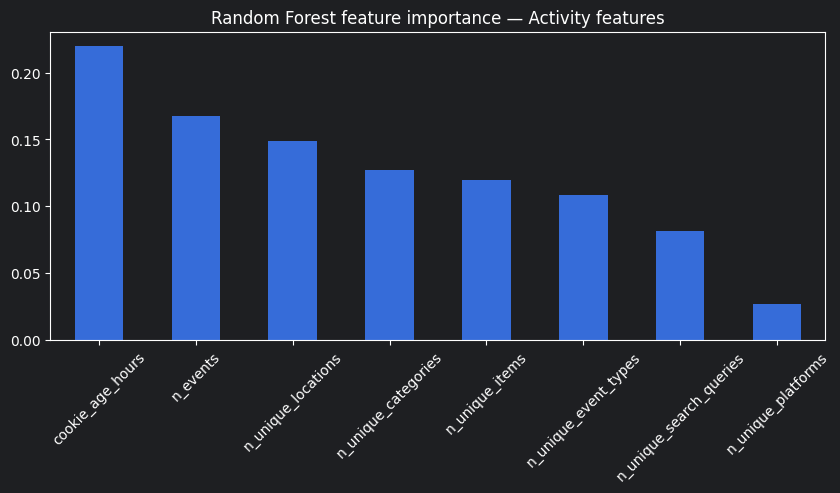

In [23]:
feature_importance.plot(
    kind="bar",
    figsize=(10, 4),
    title="Random Forest feature importance — Activity features",
    rot=45,
)

### Target по признакам

In [24]:
display(
    X_activity_train
    .groupby("target")[activity_features]
    .median()
    .T
)

target,0,1
cookie_age_hours,1482.776806,455.241667
n_events,12.000000,20.000000
n_unique_items,6.000000,10.000000
n_unique_categories,2.000000,2.000000
n_unique_locations,5.000000,8.000000
n_unique_search_queries,3.000000,4.000000
n_unique_event_types,4.000000,5.000000
n_unique_platforms,2.000000,2.000000


In [25]:
display(
    X_activity_train
    .groupby("target")[activity_features]
    .mean()
    .T
)

target,0,1
cookie_age_hours,1773.801448,1169.433860
n_events,16.869015,29.484983
n_unique_items,8.917190,13.779755
n_unique_categories,2.281201,1.787542
n_unique_locations,5.881868,9.789766
n_unique_search_queries,3.789835,4.758621
n_unique_event_types,4.598312,4.803115
n_unique_platforms,1.504023,1.657397


### Experiment 02. Распределение типов событий

#### Гипотеза

Само количество различных типов событий (`n_unique_event_types`)
не описывает поведение cookie достаточно подробно.

Две cookie могут иметь одинаковое количество типов событий, но
совершать принципиально разные действия.

Поэтому для каждого типа события построим:

- абсолютное количество событий;
- долю события среди всех событий cookie.

Так мы проверим, содержит ли структура активности дополнительный
сигнал относительно E01.

#### Валидация

Используем тот же временной holdout:

- train: `window_start_ts < 2026-04-17`;
- validation: `window_start_ts >= 2026-04-17`.

Никакие признаки не строятся по событиям за пределами
наблюдаемого окна.

In [26]:
event_types = (
    ev_train["event_name"]
    .value_counts()
    .sort_values(ascending=False)
)

event_types

event_name
item_view               74338
search_results_view     61717
photo_swipe             22951
favorite_add            12037
seller_page_view        10688
contact_phone_show       7046
login                    3900
contact_chat_open        3780
contact_message_sent     1979
Name: count, dtype: int64

In [27]:
train_event_types = set(ev_train["event_name"].unique())
test_event_types = set(ev_test["event_name"].unique())

print("Train event types:", train_event_types)
print("Test event types:", test_event_types)

assert train_event_types == test_event_types

Train event types: {'contact_message_sent', 'item_view', 'contact_chat_open', 'search_results_view', 'favorite_add', 'seller_page_view', 'login', 'contact_phone_show', 'photo_swipe'}
Test event types: {'contact_message_sent', 'contact_chat_open', 'item_view', 'search_results_view', 'favorite_add', 'seller_page_view', 'login', 'contact_phone_show', 'photo_swipe'}


### Абсолютные количества событий

In [28]:
def build_event_count_features(ev: pd.DataFrame) -> pd.DataFrame:
    counts = pd.crosstab(
        ev["cookie_id"],
        ev["event_name"],
    )

    counts.columns = [
        f"event_count__{event_type}"
        for event_type in counts.columns
    ]

    return counts.reset_index()

In [29]:
event_count_train = build_event_count_features(ev_train)
event_count_test = build_event_count_features(ev_test)

print("Train:", event_count_train.shape)
print("Test:", event_count_test.shape)

display(event_count_train.head())

Train: (11091, 10)
Test: (4909, 10)


,cookie_id,event_count__contact_chat_open,event_count__contact_message_sent,event_count__contact_phone_show,event_count__favorite_add,event_count__item_view,event_count__login,event_count__photo_swipe,event_count__search_results_view,event_count__seller_page_view
0,ck_000c95f1408dcb00,0,0,0,0,11,0,1,3,1
1,ck_000e8c52636e3bec,0,0,1,4,11,1,5,9,3
2,ck_0010e31baa4a1fb7,0,0,0,2,7,1,1,4,1
3,ck_0010ec3874fb5378,0,0,0,10,25,1,14,20,4
4,ck_001722063b94cae0,0,0,1,0,8,0,1,5,0


In [30]:
assert set(event_count_train["cookie_id"]) == set(train["cookie_id"])
assert set(event_count_test["cookie_id"]) == set(test["cookie_id"])

assert event_count_train["cookie_id"].is_unique
assert event_count_test["cookie_id"].is_unique

print("Event count feature coverage: OK")

Event count feature coverage: OK


### Доли типов событий

In [31]:
def build_event_share_features(ev: pd.DataFrame) -> pd.DataFrame:
    counts = pd.crosstab(
        ev["cookie_id"],
        ev["event_name"],
    )

    shares = counts.div(
        counts.sum(axis=1),
        axis=0,
    )

    shares.columns = [
        f"event_share__{event_type}"
        for event_type in shares.columns
    ]

    return shares.reset_index()

In [32]:
event_share_train = build_event_share_features(ev_train)
event_share_test = build_event_share_features(ev_test)

print("Train:", event_share_train.shape)
print("Test:", event_share_test.shape)

display(event_share_train.head())

Train: (11091, 10)
Test: (4909, 10)


,cookie_id,event_share__contact_chat_open,event_share__contact_message_sent,event_share__contact_phone_show,event_share__favorite_add,event_share__item_view,event_share__login,event_share__photo_swipe,event_share__search_results_view,event_share__seller_page_view
0,ck_000c95f1408dcb00,0.0,0.0,0.000000,0.000000,0.687500,0.000000,0.062500,0.187500,0.062500
1,ck_000e8c52636e3bec,0.0,0.0,0.029412,0.117647,0.323529,0.029412,0.147059,0.264706,0.088235
2,ck_0010e31baa4a1fb7,0.0,0.0,0.000000,0.125000,0.437500,0.062500,0.062500,0.250000,0.062500
3,ck_0010ec3874fb5378,0.0,0.0,0.000000,0.135135,0.337838,0.013514,0.189189,0.270270,0.054054
4,ck_001722063b94cae0,0.0,0.0,0.066667,0.000000,0.533333,0.000000,0.066667,0.333333,0.000000


In [33]:
assert set(event_share_train["cookie_id"]) == set(train["cookie_id"])
assert set(event_share_test["cookie_id"]) == set(test["cookie_id"])

assert event_share_train["cookie_id"].is_unique
assert event_share_test["cookie_id"].is_unique

print("Event share feature coverage: OK")

Event share feature coverage: OK


In [34]:
share_cols = [
    col
    for col in event_share_train.columns
    if col.startswith("event_share__")
]

share_sums = event_share_train[share_cols].sum(axis=1)

print(share_sums.describe())

assert np.allclose(
    share_sums.to_numpy(),
    1.0,
    atol=1e-12,
)

print("Event shares: OK")

count    1.109100e+04
mean     1.000000e+00
std      5.376685e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64
Event shares: OK


### Различия между target=0 и target=1

In [35]:
count_cols = [
    col
    for col in event_count_train.columns
    if col.startswith("event_count__")
]

count_analysis = (
    event_count_train
    .merge(
        train[["cookie_id", "target"]],
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
    .groupby("target")[count_cols]
    .mean()
    .T
)

count_analysis

target,0,1
event_count__contact_chat_open,0.333987,0.418242
event_count__contact_message_sent,0.173568,0.233593
event_count__contact_phone_show,0.624117,0.761958
event_count__favorite_add,1.110381,0.800890
event_count__item_view,6.158752,12.867631
event_count__login,0.362343,0.230256
event_count__photo_swipe,2.069368,2.068966
event_count__search_results_view,5.141189,10.364850
event_count__seller_page_view,0.895310,1.738598


In [36]:
share_analysis = (
    event_share_train
    .merge(
        train[["cookie_id", "target"]],
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
    .groupby("target")[share_cols]
    .mean()
    .T
)

share_analysis

target,0,1
event_share__contact_chat_open,0.016645,0.018093
event_share__contact_message_sent,0.008091,0.010416
event_share__contact_phone_show,0.030725,0.033282
event_share__favorite_add,0.068735,0.033013
event_share__item_view,0.364250,0.424916
event_share__login,0.023179,0.009808
event_share__photo_swipe,0.127041,0.078164
event_share__search_results_view,0.308472,0.331261
event_share__seller_page_view,0.052861,0.061046


### Контактные и captcha-события

In [37]:
interesting_event_types = [
    "captcha_shown",
    "contact_phone_show",
    "contact_chat_open",
    "contact_message_sent",
    "seller_page_view",
    "photo_swipe",
    "favorite_add",
    "login",
]

interesting_share_cols = [
    f"event_share__{event_type}"
    for event_type in interesting_event_types
]

interesting_count_cols = [
    f"event_count__{event_type}"
    for event_type in interesting_event_types
]

print("Mean event counts:")
display(
    count_analysis.loc[
        [col for col in interesting_count_cols if col in count_analysis.index]
    ]
)

print("Mean event shares:")
display(
    share_analysis.loc[
        [col for col in interesting_share_cols if col in share_analysis.index]
    ]
)

Mean event counts:


target,0,1
event_count__contact_phone_show,0.624117,0.761958
event_count__contact_chat_open,0.333987,0.418242
event_count__contact_message_sent,0.173568,0.233593
event_count__seller_page_view,0.895310,1.738598
event_count__photo_swipe,2.069368,2.068966
event_count__favorite_add,1.110381,0.800890
event_count__login,0.362343,0.230256


Mean event shares:


target,0,1
event_share__contact_phone_show,0.030725,0.033282
event_share__contact_chat_open,0.016645,0.018093
event_share__contact_message_sent,0.008091,0.010416
event_share__seller_page_view,0.052861,0.061046
event_share__photo_swipe,0.127041,0.078164
event_share__favorite_add,0.068735,0.033013
event_share__login,0.023179,0.009808


In [38]:
X_event_train = (
    X_activity_train
    .merge(
        event_count_train,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        event_share_train,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
)

X_event_test = (
    X_activity_test
    .merge(
        event_count_test,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        event_share_test,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
)

print("Train:", X_event_train.shape)
print("Test:", X_event_test.shape)

Train: (11091, 32)
Test: (4909, 31)


In [39]:
e02_features = count_cols + share_cols

print(
    "Missing E02 features:",
    X_event_train[e02_features].isna().sum().sum(),
)

assert X_event_train[e02_features].isna().sum().sum() == 0
assert X_event_test[e02_features].isna().sum().sum() == 0

print("E02 feature matrix: OK")

Missing E02 features: 0
E02 feature matrix: OK


In [40]:
e02_features = (
    activity_features
    + count_cols
    + share_cols
)

model_e02, scores_e02, metrics_e02 = fit_evaluate_rf(
    X=X_event_train,
    feature_cols=e02_features,
    train_mask=~is_valid.to_numpy(),
    valid_mask=is_valid.to_numpy(),
    y=y_activity,
    random_state=0,
)

metrics_e02

{'P@R>=0.70': 0.24242424242424243,
 'PR-AUC': 0.47356730774780303,
 'ROC-AUC': 0.8102683556672251}

### Обновляем таблицу экспериментов

In [41]:
experiment_results = pd.DataFrame([
    {
        "experiment": "E00_baseline",
        "feature_group": "quickstart",
        **metrics_baseline,
    },
    {
        "experiment": "E01_activity",
        "feature_group": "metadata + activity",
        **metrics_activity,
    },
    {
        "experiment": "E02_event_distribution",
        "feature_group": "E01 + event counts + event shares",
        **metrics_e02,
    },
])

experiment_results

,experiment,feature_group,P@R>=0.70,PR-AUC,ROC-AUC
0,E00_baseline,quickstart,0.102470,0.174609,0.607396
1,E01_activity,metadata + activity,0.210037,0.379974,0.790239
2,E02_event_distribution,E01 + event counts + event shares,0.242424,0.473567,0.810268


### Feature importance

In [42]:
feature_importance_e02 = (
    pd.Series(
        model_e02.feature_importances_,
        index=e02_features,
        name="importance",
    )
    .sort_values(ascending=False)
)

display(feature_importance_e02.head(25))

cookie_age_hours                     0.096515
event_count__item_view               0.075553
n_unique_locations                   0.071386
event_share__item_view               0.061588
n_unique_categories                  0.061519
event_share__photo_swipe             0.058933
event_share__search_results_view     0.057967
event_count__search_results_view     0.057651
event_share__favorite_add            0.054311
n_events                             0.050860
n_unique_items                       0.043436
event_share__contact_phone_show      0.038341
event_share__seller_page_view        0.034853
n_unique_event_types                 0.031017
n_unique_search_queries              0.028490
event_share__contact_chat_open       0.023261
event_count__seller_page_view        0.022739
event_count__contact_phone_show      0.022299
event_count__favorite_add            0.021759
event_count__photo_swipe             0.020855
n_unique_platforms                   0.014837
event_share__login                

In [43]:
e02_importance = (
    feature_importance_e02[
        feature_importance_e02.index.isin(count_cols + share_cols)
    ]
    .sort_values(ascending=False)
)

display(e02_importance)

event_count__item_view               0.075553
event_share__item_view               0.061588
event_share__photo_swipe             0.058933
event_share__search_results_view     0.057967
event_count__search_results_view     0.057651
event_share__favorite_add            0.054311
event_share__contact_phone_show      0.038341
event_share__seller_page_view        0.034853
event_share__contact_chat_open       0.023261
event_count__seller_page_view        0.022739
event_count__contact_phone_show      0.022299
event_count__favorite_add            0.021759
event_count__photo_swipe             0.020855
event_share__login                   0.014089
event_share__contact_message_sent    0.013919
event_count__contact_chat_open       0.011617
event_count__contact_message_sent    0.006314
event_count__login                   0.005891
Name: importance, dtype: float64

### Experiment 03. Temporal behavior

Исследуем временную структуру активности cookie внутри суточного окна.

Гипотезы:

1. Автоматизированный трафик может иметь другую интенсивность событий.
2. Боты могут генерировать события более равномерно или, наоборот, формировать короткие плотные серии.
3. Для разных классов может отличаться длительность активной сессии.
4. Важными сигналами могут быть количество активных часов и интервалы между событиями.

Для каждой cookie рассчитываются относительные временные характеристики:
- время первого и последнего события относительно начала окна;
- длительность активного периода;
- число активных часов;
- статистики межсобытийных интервалов;
- интенсивность событий;
- burstiness;
- локальная плотность событий.

Абсолютные timestamps не используются, чтобы модель не могла напрямую запоминать календарный период.

### Базовая проверка временного порядка

In [44]:
# Проверяем, что события внутри каждой cookie идут в хронологическом порядке.
for df, name in [(ev_train, "train"), (ev_test, "test")]:
    is_sorted = (
        df.groupby("cookie_id")["event_ts"]
        .apply(lambda s: s.is_monotonic_increasing)
        .all()
    )

    print(f"{name}: sorted by event_ts = {is_sorted}")

train: sorted by event_ts = True
test: sorted by event_ts = True


### Функция временных признаков

In [45]:
def build_temporal_features(ev):
    """
    Строит временные признаки активности для каждой cookie_id.

    Все временные характеристики рассчитываются относительно
    начала соответствующего observation window.
    """
    df = ev[
        [
            "cookie_id",
            "event_ts",
            "window_start_ts",
            "window_end_ts",
        ]
    ].copy()

    # Время события относительно начала окна.
    df["event_offset_seconds"] = (
        df["event_ts"] - df["window_start_ts"]
    ).dt.total_seconds()

    # Межсобытийный интервал внутри cookie.
    df["inter_event_seconds"] = (
        df.groupby("cookie_id", sort=False)["event_ts"]
        .diff()
        .dt.total_seconds()
    )

    # Номер часа относительно начала окна.
    df["relative_hour"] = (
        df["event_offset_seconds"] // 3600
    ).astype(int)

    g = df.groupby("cookie_id", sort=False)

    # Базовые временные характеристики.
    features = g.agg(
        first_event_offset_seconds=("event_offset_seconds", "min"),
        last_event_offset_seconds=("event_offset_seconds", "max"),
        n_active_hours=("relative_hour", "nunique"),
        mean_inter_event_seconds=("inter_event_seconds", "mean"),
        median_inter_event_seconds=("inter_event_seconds", "median"),
        std_inter_event_seconds=("inter_event_seconds", "std"),
        min_inter_event_seconds=("inter_event_seconds", "min"),
        max_inter_event_seconds=("inter_event_seconds", "max"),
    ).reset_index()

    # Длительность активности.
    features["active_span_seconds"] = (
        features["last_event_offset_seconds"]
        - features["first_event_offset_seconds"]
    )

    # Интенсивность событий во время активного периода.
    # +1 секунда защищает от деления на ноль для cookie с одним событием.
    n_events = g.size().rename("n_events").reset_index()

    features = features.merge(
        n_events,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )

    features["events_per_active_hour"] = (
        features["n_events"]
        / (features["active_span_seconds"] / 3600 + 1)
    )

    # Burstiness:
    # (std - mean) / (std + mean)
    # Значения ближе к -1 соответствуют более регулярным интервалам,
    # большие значения — более неоднородному распределению интервалов.
    denominator = (
        features["std_inter_event_seconds"]
        + features["mean_inter_event_seconds"]
    )

    features["inter_event_burstiness"] = (
        (
            features["std_inter_event_seconds"]
            - features["mean_inter_event_seconds"]
        )
        / denominator.replace(0, np.nan)
    )

    # Для cookie с одним событием межсобытийные признаки отсутствуют.
    # Это корректно: интервал определить невозможно.
    interval_cols = [
        "mean_inter_event_seconds",
        "median_inter_event_seconds",
        "std_inter_event_seconds",
        "min_inter_event_seconds",
        "max_inter_event_seconds",
        "inter_event_burstiness",
    ]

    features[interval_cols] = features[interval_cols].fillna(0.0)

    return features

### Построение E03

In [46]:
temporal_train = build_temporal_features(ev_train)
temporal_test = build_temporal_features(ev_test)

print("train:", temporal_train.shape)
print("test :", temporal_test.shape)

display(temporal_train.head())

train: (11091, 13)
test : (4909, 13)


,cookie_id,first_event_offset_seconds,last_event_offset_seconds,n_active_hours,mean_inter_event_seconds,median_inter_event_seconds,std_inter_event_seconds,min_inter_event_seconds,max_inter_event_seconds,active_span_seconds,n_events,events_per_active_hour,inter_event_burstiness
0,ck_000c95f1408dcb00,53394.0,83511.0,6,2007.800000,58.0,3080.553503,17.0,7733.0,30117.0,16,1.708337,0.210825
1,ck_000e8c52636e3bec,23160.0,29841.0,3,202.454545,23.0,774.305983,0.0,4257.0,6681.0,34,11.905457,0.585457
2,ck_0010e31baa4a1fb7,42798.0,85174.0,8,2825.066667,334.0,3107.706813,10.0,8243.0,42376.0,16,1.252828,0.047640
3,ck_0010ec3874fb5378,7703.0,64767.0,11,781.698630,32.0,1984.404925,0.0,8567.0,57064.0,74,4.391402,0.434802
4,ck_001722063b94cae0,65229.0,69347.0,2,294.142857,175.0,427.831357,2.0,1447.0,4118.0,15,6.996631,0.185171


### Проверяем покрытие

In [47]:
assert temporal_train["cookie_id"].is_unique
assert temporal_test["cookie_id"].is_unique

assert set(temporal_train["cookie_id"]) == set(train["cookie_id"])
assert set(temporal_test["cookie_id"]) == set(test["cookie_id"])

print("Temporal feature coverage: OK")

Temporal feature coverage: OK


### Проверка диапазонов

In [48]:
temporal_train.describe().T

,count,mean,std,min,25%,50%,75%,max
first_event_offset_seconds,11091.0,46516.523758,23919.932194,3.000000,27973.000000,47901.000000,67597.500000,86372.000000
last_event_offset_seconds,11091.0,58175.573889,23371.757767,475.000000,40506.000000,62800.000000,80232.500000,86399.000000
n_active_hours,11091.0,3.139663,2.221963,1.000000,2.000000,3.000000,4.000000,17.000000
mean_inter_event_seconds,11091.0,798.362763,846.914324,0.000000,187.000000,616.357143,1088.026316,9005.000000
median_inter_event_seconds,11091.0,204.813948,730.553800,0.000000,33.000000,55.000000,95.000000,9005.000000
std_inter_event_seconds,11091.0,1522.593902,1149.931652,0.000000,239.789899,1623.807077,2307.235233,6356.182856
min_inter_event_seconds,11091.0,56.062213,472.428876,0.000000,0.000000,4.000000,15.000000,9005.000000
max_inter_event_seconds,11091.0,4861.529799,3263.670462,0.000000,1137.000000,5777.000000,7838.500000,9760.000000
active_span_seconds,11091.0,11659.050131,12264.458263,0.000000,1773.500000,8410.000000,16742.500000,83488.000000
n_events,11091.0,17.891624,17.706829,1.000000,6.000000,12.000000,23.000000,169.000000


In [49]:
temporal_checks = pd.DataFrame({
    "feature": [
        "first_event_offset_seconds",
        "last_event_offset_seconds",
        "active_span_seconds",
        "n_active_hours",
        "events_per_active_hour",
        "mean_inter_event_seconds",
        "median_inter_event_seconds",
        "min_inter_event_seconds",
        "max_inter_event_seconds",
    ],
    "min": [
        temporal_train[c].min()
        for c in [
            "first_event_offset_seconds",
            "last_event_offset_seconds",
            "active_span_seconds",
            "n_active_hours",
            "events_per_active_hour",
            "mean_inter_event_seconds",
            "median_inter_event_seconds",
            "min_inter_event_seconds",
            "max_inter_event_seconds",
        ]
    ],
    "max": [
        temporal_train[c].max()
        for c in [
            "first_event_offset_seconds",
            "last_event_offset_seconds",
            "active_span_seconds",
            "n_active_hours",
            "events_per_active_hour",
            "mean_inter_event_seconds",
            "median_inter_event_seconds",
            "min_inter_event_seconds",
            "max_inter_event_seconds",
        ]
    ],
})

display(temporal_checks)

,feature,min,max
0,first_event_offset_seconds,3.000000,86372.000000
1,last_event_offset_seconds,475.000000,86399.000000
2,active_span_seconds,0.000000,83488.000000
3,n_active_hours,1.000000,17.000000
4,events_per_active_hour,0.525317,81.365713
5,mean_inter_event_seconds,0.000000,9005.000000
6,median_inter_event_seconds,0.000000,9005.000000
7,min_inter_event_seconds,0.000000,9005.000000
8,max_inter_event_seconds,0.000000,9760.000000


In [50]:
assert temporal_train["first_event_offset_seconds"].min() >= 0
assert temporal_train["last_event_offset_seconds"].max() < 24 * 3600

assert temporal_train["active_span_seconds"].min() >= 0
assert temporal_train["n_active_hours"].min() >= 1

assert temporal_test["first_event_offset_seconds"].min() >= 0
assert temporal_test["last_event_offset_seconds"].max() < 24 * 3600

print("Temporal ranges: OK")

Temporal ranges: OK


### Посмотрим различия между классами

In [51]:
temporal_analysis = (
    temporal_train
    .merge(
        train[["cookie_id", "target"]],
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
)

temporal_cols = [
    c for c in temporal_train.columns
    if c != "cookie_id"
]

temporal_class_stats = (
    temporal_analysis
    .groupby("target")[temporal_cols]
    .agg(["mean", "median"])
    .T
)

display(temporal_class_stats)

target                                        0             1
first_event_offset_seconds mean    46919.408163  41949.006674
                           median  48318.500000  42829.000000
last_event_offset_seconds  mean    58541.076825  54031.852058
                           median  63117.000000  57716.000000
n_active_hours             mean        3.132457      3.221357
                           median      3.000000      3.000000
mean_inter_event_seconds   mean      819.418941    559.648005
                           median    637.551020    424.042553
median_inter_event_seconds mean      214.100765     99.528921
                           median     57.500000     24.000000
std_inter_event_seconds    mean     1541.741784   1305.513580
                           median   1654.627318   1346.577266
min_inter_event_seconds    mean       57.775118     36.642937
                           median      5.000000      3.000000
max_inter_event_seconds    mean     4845.397763   5044.419355
                           median   5753.500000   6001.000000
active_span_seconds        mean    11621.668662  12082.845384
                           median   8326.500000   9092.000000
n_events                   mean       16.869015     29.484983
                           median     12.000000     20.000000
events_per_active_hour     mean        4.373750      7.958526
                           median      3.643396      5.718724
inter_event_burstiness     mean        0.253275      0.311002
                           median      0.330422      0.443229

### Отдельно посмотрим ключевые временные признаки

In [52]:
key_temporal_cols = [
    "first_event_offset_seconds",
    "last_event_offset_seconds",
    "active_span_seconds",
    "n_active_hours",
    "events_per_active_hour",
    "mean_inter_event_seconds",
    "median_inter_event_seconds",
    "inter_event_burstiness",
]

display(
    temporal_analysis
    .groupby("target")[key_temporal_cols]
    .agg(["mean", "median"])
    .T
)

target                                        0             1
first_event_offset_seconds mean    46919.408163  41949.006674
                           median  48318.500000  42829.000000
last_event_offset_seconds  mean    58541.076825  54031.852058
                           median  63117.000000  57716.000000
active_span_seconds        mean    11621.668662  12082.845384
                           median   8326.500000   9092.000000
n_active_hours             mean        3.132457      3.221357
                           median      3.000000      3.000000
events_per_active_hour     mean        4.373750      7.958526
                           median      3.643396      5.718724
mean_inter_event_seconds   mean      819.418941    559.648005
                           median    637.551020    424.042553
median_inter_event_seconds mean      214.100765     99.528921
                           median     57.500000     24.000000
inter_event_burstiness     mean        0.253275      0.311002
                           median      0.330422      0.443229

### Добавляем E03 к E02

In [53]:
X_e03_train = X_event_train.merge(
    temporal_train,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)

X_e03_test = X_event_test.merge(
    temporal_test,
    on="cookie_id",
    how="left",
    validate="one_to_one",
)

print("E02 train:", X_event_train.shape)
print("E03 train:", X_e03_train.shape)

print("E02 test :", X_event_test.shape)
print("E03 test :", X_e03_test.shape)

E02 train: (11091, 32)
E03 train: (11091, 44)
E02 test : (4909, 31)
E03 test : (4909, 43)


In [54]:
assert len(X_e03_train) == len(train)
assert len(X_e03_test) == len(test)

assert X_e03_train["cookie_id"].is_unique
assert X_e03_test["cookie_id"].is_unique

print("E02 + E03 merge: OK")

E02 + E03 merge: OK


### Список признаков E03

In [65]:
temporal_feature_cols = [
    c for c in temporal_train.columns
    if c != "cookie_id"
]

metadata_cols = {
    "cookie_id",
    "cookie_created_at",
    "window_start_ts",
    "window_end_ts",
    "target",
}

e03_feature_cols = [
    c for c in X_e03_train.columns
    if c not in metadata_cols
]

print("Number of features:", len(e03_feature_cols))
print(e03_feature_cols)
print()
print(temporal_feature_cols)

Number of features: 39
['cookie_age_seconds', 'cookie_age_hours', 'n_events_x', 'n_unique_items', 'n_unique_categories', 'n_unique_locations', 'n_unique_search_queries', 'n_unique_event_types', 'n_unique_platforms', 'event_count__contact_chat_open', 'event_count__contact_message_sent', 'event_count__contact_phone_show', 'event_count__favorite_add', 'event_count__item_view', 'event_count__login', 'event_count__photo_swipe', 'event_count__search_results_view', 'event_count__seller_page_view', 'event_share__contact_chat_open', 'event_share__contact_message_sent', 'event_share__contact_phone_show', 'event_share__favorite_add', 'event_share__item_view', 'event_share__login', 'event_share__photo_swipe', 'event_share__search_results_view', 'event_share__seller_page_view', 'first_event_offset_seconds', 'last_event_offset_seconds', 'n_active_hours', 'mean_inter_event_seconds', 'median_inter_event_seconds', 'std_inter_event_seconds', 'min_inter_event_seconds', 'max_inter_event_seconds', 'active_

### Проверка отсутствующих значений

In [66]:
missing_e03 = (
    X_e03_train[e03_feature_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(missing_e03[missing_e03 > 0])

Series([], dtype: int64)

In [67]:
assert X_e03_train[e03_feature_cols].isna().sum().sum() == 0
assert X_e03_test[e03_feature_cols].isna().sum().sum() == 0

print("E03 missing values: OK")

E03 missing values: OK


### Контрольная проверка временной утечки

In [68]:
for df, name in [(ev_train, "train"), (ev_test, "test")]:
    assert (
        (df["event_ts"] >= df["window_start_ts"])
        & (df["event_ts"] < df["window_end_ts"])
    ).all()

    print(f"{name}: no events outside observation window")

train: no events outside observation window
test: no events outside observation window


### Обучение той же модели

In [69]:
model_e03, valid_scores_e03, metrics_e03 = fit_evaluate_rf(
    X_e03_train,
    e03_feature_cols,
    is_valid,
    ~is_valid,
    train["target"],
    random_state=0,
)

metrics_e03

{'P@R>=0.70': 0.33226427196921104,
 'PR-AUC': 0.6069801746377597,
 'ROC-AUC': 0.8501553314018452}

### E03 добавляем в таблицу экспериментов

In [70]:
experiment_results = pd.DataFrame([
    {
        "experiment": "E00",
        "feature_group": "baseline",
        **metrics_baseline,
    },
    {
        "experiment": "E01",
        "feature_group": "activity",
        **metrics_activity,
    },
    {
        "experiment": "E02",
        "feature_group": "event distribution",
        **metrics_e02,
    },
    {
        "experiment": "E03",
        "feature_group": "activity + event distribution + temporal",
        **metrics_e03,
    },
])

display(experiment_results)

,experiment,feature_group,P@R>=0.70,PR-AUC,ROC-AUC
0,E00,baseline,0.102470,0.174609,0.607396
1,E01,activity,0.210037,0.379974,0.790239
2,E02,event distribution,0.242424,0.473567,0.810268
3,E03,activity + event distribution + temporal,0.332264,0.606980,0.850155


### Относительный прирост

In [71]:
e02_p = metrics_e02["P@R>=0.70"]
e03_p = metrics_e03["P@R>=0.70"]

relative_gain = (e03_p / e02_p - 1) * 100

print(f"E02 P@R>=0.70: {e02_p:.6f}")
print(f"E03 P@R>=0.70: {e03_p:.6f}")
print(f"Relative change: {relative_gain:+.2f}%")

E02 P@R>=0.70: 0.242424
E03 P@R>=0.70: 0.332264
Relative change: +37.06%


### Feature importance E03

In [72]:
feature_importance_e03 = (
    pd.Series(
        model_e03.feature_importances_,
        index=e03_feature_cols,
        name="importance",
    )
    .sort_values(ascending=False)
)

display(feature_importance_e03.head(30))

median_inter_event_seconds          0.132267
inter_event_burstiness              0.058372
cookie_age_hours                    0.049050
events_per_active_hour              0.044112
cookie_age_seconds                  0.042773
n_unique_locations                  0.040435
event_count__item_view              0.037216
min_inter_event_seconds             0.035034
event_share__photo_swipe            0.033689
last_event_offset_seconds           0.032507
mean_inter_event_seconds            0.030323
event_share__item_view              0.028650
active_span_seconds                 0.027759
n_events_x                          0.027734
std_inter_event_seconds             0.027399
max_inter_event_seconds             0.027107
first_event_offset_seconds          0.026922
n_unique_categories                 0.025696
n_events_y                          0.025577
event_share__seller_page_view       0.022869
event_share__contact_phone_show     0.022719
n_unique_items                      0.022557
event_coun

In [73]:
display(
    feature_importance_e03[
        feature_importance_e03.index.isin(temporal_feature_cols)
    ].sort_values(ascending=False)
)

median_inter_event_seconds    0.132267
inter_event_burstiness        0.058372
events_per_active_hour        0.044112
min_inter_event_seconds       0.035034
last_event_offset_seconds     0.032507
mean_inter_event_seconds      0.030323
active_span_seconds           0.027759
std_inter_event_seconds       0.027399
max_inter_event_seconds       0.027107
first_event_offset_seconds    0.026922
n_active_hours                0.006952
Name: importance, dtype: float64

### Важная дополнительная проверка: один event

In [74]:
single_event_share = (
    (temporal_train["n_events"] == 1).mean()
)

print(f"Cookies with one event: {single_event_share:.4%}")

Cookies with one event: 2.2270%


In [75]:
single_event_temporal = temporal_train.loc[
    temporal_train["n_events"] == 1,
    [
        "mean_inter_event_seconds",
        "median_inter_event_seconds",
        "std_inter_event_seconds",
        "min_inter_event_seconds",
        "max_inter_event_seconds",
        "inter_event_burstiness",
    ],
]

display(single_event_temporal.head())

,mean_inter_event_seconds,median_inter_event_seconds,std_inter_event_seconds,min_inter_event_seconds,max_inter_event_seconds,inter_event_burstiness
8,0.0,0.0,0.0,0.0,0.0,0.0
71,0.0,0.0,0.0,0.0,0.0,0.0
113,0.0,0.0,0.0,0.0,0.0,0.0
142,0.0,0.0,0.0,0.0,0.0,0.0
169,0.0,0.0,0.0,0.0,0.0,0.0


### Experiment 04. User-Agent and platform behavior

Исследуем технические характеристики клиентского трафика.

Гипотеза: автоматизированные сервисы могут отличаться от человеческого трафика
по User-Agent, типу клиента и распределению платформ.

Raw User-Agent не используется напрямую из-за высокой кардинальности.
Вместо него извлекаются устойчивые бинарные признаки и агрегаты:

- семейство операционной системы;
- семейство браузера;
- mobile/desktop;
- признаки headless и известных automation-инструментов;
- длина User-Agent;
- число уникальных User-Agent внутри cookie.

Дополнительно рассчитываются количества и доли событий по нормализованной платформе.

Признаки строятся только по событиям внутри observation window.

In [76]:
ua_examples = (
    ev_train["user_agent"]
    .value_counts()
    .head(30)
)

display(ua_examples)

user_agent
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 YaBrowser/23.0.0.0 Safari/537.36     2330
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 YaBrowser/23.11.0.0 Safari/537.36    2254
Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36                  2252
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 YaBrowser/23.9.0.0 Safari/537.36     2182
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 YaBrowser/23.3.0.0 Safari/537.36     2181
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/116.0.0.0 YaBrowser/23.8.0.0 Safari/537.36     2169
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0.0.0 Safari/537.36                        2168
Mozilla/5

In [77]:
print("Unique User-Agent values:", ev_train["user_agent"].nunique())

Unique User-Agent values: 148


In [78]:
display(
    ev_train[
        ["user_agent", "platform_normalized"]
    ]
    .drop_duplicates()
    .head(30)
)

,user_agent,platform_normalized
0,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,web
9,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,desktop
16,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,web
20,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,desktop
50,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,web
51,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,desktop
66,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,web
71,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,desktop
140,Mozilla/5.0 (Linux; Android 13; Redmi Note 11)...,android
155,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,web


### Нормализация User-Agent

In [79]:
def normalize_user_agent(value):
    if pd.isna(value):
        return ""
    return str(value).strip().lower()

### Извлечение технических признаков

In [80]:
def parse_user_agent_features(ua):
    """
    Извлекает устойчивые технические признаки из User-Agent.

    Функция не пытается определить точную версию браузера или ОС.
    Цель — получить устойчивые признаки клиентского окружения.
    """
    ua = normalize_user_agent(ua)

    return {
        "ua_len": len(ua),

        # OS
        "ua_is_windows": int("windows" in ua),
        "ua_is_macos": int(
            ("macintosh" in ua) or ("mac os x" in ua)
        ),
        "ua_is_linux": int(
            ("linux" in ua) and ("android" not in ua)
        ),
        "ua_is_android": int("android" in ua),
        "ua_is_ios": int(
            ("iphone" in ua)
            or ("ipad" in ua)
            or ("ipod" in ua)
            or ("ios" in ua)
        ),

        # Device class
        "ua_is_mobile": int(
            any(
                token in ua
                for token in [
                    "mobile",
                    "android",
                    "iphone",
                    "ipad",
                    "ipod",
                ]
            )
        ),

        # Browsers
        "ua_is_chrome": int(
            ("chrome" in ua)
            or ("chromium" in ua)
        ),
        "ua_is_safari": int(
            ("safari" in ua)
            and ("chrome" not in ua)
            and ("chromium" not in ua)
        ),
        "ua_is_firefox": int("firefox" in ua),
        "ua_is_edge": int(
            ("edg/" in ua)
            or ("edge/" in ua)
        ),

        # Automation / headless
        "ua_is_headless": int(
            "headless" in ua
        ),
        "ua_is_selenium": int(
            "selenium" in ua
        ),
        "ua_is_playwright": int(
            "playwright" in ua
        ),
        "ua_is_phantomjs": int(
            "phantomjs" in ua
        ),

        # Programmatic HTTP clients / crawlers
        "ua_is_python": int(
            ("python-requests" in ua)
            or ("python/" in ua)
            or ("python " in ua)
        ),
        "ua_is_curl": int("curl/" in ua),
        "ua_is_wget": int("wget/" in ua),

        # Generic automation/crawler markers
        "ua_has_automation_marker": int(
            any(
                token in ua
                for token in [
                    "headless",
                    "selenium",
                    "playwright",
                    "phantomjs",
                    "webdriver",
                    "crawler",
                    "spider",
                    "scraper",
                    "bot/",
                    "bot ",
                ]
            )
        ),
    }

### Применяем parser

In [81]:
ua_train_parsed = (
    ev_train["user_agent"]
    .map(parse_user_agent_features)
    .apply(pd.Series)
)

ua_test_parsed = (
    ev_test["user_agent"]
    .map(parse_user_agent_features)
    .apply(pd.Series)
)

print("UA event-level train:", ua_train_parsed.shape)
print("UA event-level test :", ua_test_parsed.shape)

UA event-level train: (198436, 19)
UA event-level test : (89690, 19)


### Проверяем значения

In [83]:
display(ua_train_parsed.head())

,ua_len,ua_is_windows,ua_is_macos,ua_is_linux,ua_is_android,ua_is_ios,ua_is_mobile,ua_is_chrome,ua_is_safari,ua_is_firefox,ua_is_edge,ua_is_headless,ua_is_selenium,ua_is_playwright,ua_is_phantomjs,ua_is_python,ua_is_curl,ua_is_wget,ua_has_automation_marker
0,117,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,117,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,117,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,117,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
4,117,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0


In [84]:
display(
    ua_train_parsed
    .mean()
    .sort_values(ascending=False)
)

ua_len                      98.443836
ua_is_chrome                 0.647035
ua_is_mobile                 0.445630
ua_is_android                0.393028
ua_is_windows                0.372110
ua_is_macos                  0.143285
ua_is_firefox                0.128268
ua_is_ios                    0.052601
ua_is_linux                  0.035291
ua_has_automation_marker     0.035291
ua_is_headless               0.035291
ua_is_safari                 0.017628
ua_is_curl                   0.004223
ua_is_python                 0.002741
ua_is_edge                   0.000000
ua_is_phantomjs              0.000000
ua_is_playwright             0.000000
ua_is_selenium               0.000000
ua_is_wget                   0.000000
dtype: float64

### Проверяем automation-маркеры

In [85]:
automation_cols = [
    "ua_is_headless",
    "ua_is_selenium",
    "ua_is_playwright",
    "ua_is_phantomjs",
    "ua_is_python",
    "ua_is_curl",
    "ua_is_wget",
    "ua_has_automation_marker",
]

display(
    ua_train_parsed[automation_cols]
    .mean()
    .sort_values(ascending=False)
)

ua_is_headless              0.035291
ua_has_automation_marker    0.035291
ua_is_curl                  0.004223
ua_is_python                0.002741
ua_is_phantomjs             0.000000
ua_is_playwright            0.000000
ua_is_selenium              0.000000
ua_is_wget                  0.000000
dtype: float64

### Агрегируем UA на уровень cookie

In [86]:
def build_ua_features(ev, ua_parsed):
    """
    Агрегирует User-Agent признаки с уровня событий до cookie_id.
    """
    tmp = pd.concat(
        [
            ev[["cookie_id", "user_agent"]].reset_index(drop=True),
            ua_parsed.reset_index(drop=True),
        ],
        axis=1,
    )

    tmp["user_agent_normalized"] = (
        tmp["user_agent"].map(normalize_user_agent)
    )

    g = tmp.groupby("cookie_id", sort=False)

    features = g.agg(
        n_unique_user_agents=(
            "user_agent_normalized",
            "nunique",
        ),
        mean_ua_len=("ua_len", "mean"),
        min_ua_len=("ua_len", "min"),
        max_ua_len=("ua_len", "max"),
    ).reset_index()

    binary_cols = [
        c
        for c in ua_parsed.columns
        if c.startswith("ua_is_")
        or c == "ua_has_automation_marker"
    ]

    binary_agg = (
        g[binary_cols]
        .mean()
        .reset_index()
    )

    features = features.merge(
        binary_agg,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )

    return features

### Строим UA features

In [87]:
ua_train = build_ua_features(
    ev_train,
    ua_train_parsed,
)

ua_test = build_ua_features(
    ev_test,
    ua_test_parsed,
)

print("UA train:", ua_train.shape)
print("UA test :", ua_test.shape)

UA train: (11091, 23)
UA test : (4909, 23)


In [88]:
assert ua_train["cookie_id"].is_unique
assert ua_test["cookie_id"].is_unique

assert set(ua_train["cookie_id"]) == set(train["cookie_id"])
assert set(ua_test["cookie_id"]) == set(test["cookie_id"])

print("UA feature coverage: OK")

UA feature coverage: OK


In [89]:
def build_platform_features(ev):
    """
    Строит количество и долю событий по нормализованной платформе.
    """
    counts = pd.crosstab(
        ev["cookie_id"],
        ev["platform_normalized"],
    )

    counts.columns = [
        f"platform_count__{col}"
        for col in counts.columns
    ]

    counts = counts.reset_index()

    shares = pd.crosstab(
        ev["cookie_id"],
        ev["platform_normalized"],
        normalize="index",
    )

    shares.columns = [
        f"platform_share__{col}"
        for col in shares.columns
    ]

    shares = shares.reset_index()

    features = counts.merge(
        shares,
        on="cookie_id",
        how="outer",
        validate="one_to_one",
    )

    return features

In [90]:
platform_train = build_platform_features(ev_train)
platform_test = build_platform_features(ev_test)

print("Platform train:", platform_train.shape)
print("Platform test :", platform_test.shape)

Platform train: (11091, 11)
Platform test : (4909, 11)


### Проверяем platform features

In [91]:
platform_train.head()

,cookie_id,platform_count__android,platform_count__desktop,platform_count__ios,platform_count__iphone,platform_count__web,platform_share__android,platform_share__desktop,platform_share__ios,platform_share__iphone,platform_share__web
0,ck_000c95f1408dcb00,0,1,0,0,15,0.0,0.062500,0.0,0.0,0.937500
1,ck_000e8c52636e3bec,0,14,0,0,20,0.0,0.411765,0.0,0.0,0.588235
2,ck_0010e31baa4a1fb7,0,5,0,0,11,0.0,0.312500,0.0,0.0,0.687500
3,ck_0010ec3874fb5378,0,17,0,0,57,0.0,0.229730,0.0,0.0,0.770270
4,ck_001722063b94cae0,15,0,0,0,0,1.0,0.000000,0.0,0.0,0.000000


In [92]:
platform_share_cols = [
    c
    for c in platform_train.columns
    if c.startswith("platform_share__")
]

share_sums = platform_train[platform_share_cols].sum(axis=1)

print("Max deviation from 1:")
print(np.abs(share_sums - 1).max())

Max deviation from 1:
0.0


In [93]:
assert np.allclose(
    platform_train[platform_share_cols].sum(axis=1),
    1.0,
)

print("Platform shares: OK")

Platform shares: OK


### Проверяем train/test категории

In [94]:
train_platform_cols = set(platform_train.columns)
test_platform_cols = set(platform_test.columns)

print("Train-only columns:")
print(train_platform_cols - test_platform_cols)

print("Test-only columns:")
print(test_platform_cols - train_platform_cols)

Train-only columns:
set()
Test-only columns:
set()


In [95]:
def align_feature_columns(train_features, test_features):
    """
    Выравнивает набор признаков train/test.
    Отсутствующие категории получают 0.
    """
    train_features = train_features.copy()
    test_features = test_features.copy()

    all_cols = sorted(
        set(train_features.columns)
        | set(test_features.columns)
    )

    all_cols.remove("cookie_id")

    for col in all_cols:
        if col not in train_features:
            train_features[col] = 0

        if col not in test_features:
            test_features[col] = 0

    train_features = train_features[
        ["cookie_id"] + all_cols
    ]

    test_features = test_features[
        ["cookie_id"] + all_cols
    ]

    return train_features, test_features

In [96]:
platform_train, platform_test = align_feature_columns(
    platform_train,
    platform_test,
)

print(platform_train.shape)
print(platform_test.shape)

(11091, 11)
(4909, 11)


### Анализ UA по target

In [97]:
ua_analysis = (
    ua_train
    .merge(
        train[["cookie_id", "target"]],
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
)

In [98]:
ua_feature_cols = [
    c
    for c in ua_train.columns
    if c != "cookie_id"
]

display(
    ua_analysis
    .groupby("target")[ua_feature_cols]
    .mean()
    .T
)

target,0,1
n_unique_user_agents,1.135793,1.112347
mean_ua_len,98.752778,92.318187
min_ua_len,97.672684,91.486096
max_ua_len,99.725177,93.130145
ua_is_windows,0.362317,0.395659
ua_is_macos,0.142491,0.136043
ua_is_linux,0.020703,0.083426
ua_is_android,0.422881,0.317019
ua_is_ios,0.054258,0.028921
ua_is_mobile,0.477139,0.345940


In [99]:
display(
    ua_analysis
    .groupby("target")[automation_cols]
    .mean()
    .T
)

target,0,1
ua_is_headless,0.020703,0.083426
ua_is_selenium,0.000000,0.000000
ua_is_playwright,0.000000,0.000000
ua_is_phantomjs,0.000000,0.000000
ua_is_python,0.002159,0.005562
ua_is_curl,0.002355,0.008899
ua_is_wget,0.000000,0.000000
ua_has_automation_marker,0.020703,0.083426


### Platform analysis

In [100]:
platform_analysis = (
    platform_train
    .merge(
        train[["cookie_id", "target"]],
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
)

In [101]:
platform_count_cols = [
    c
    for c in platform_train.columns
    if c.startswith("platform_count__")
]

display(
    platform_analysis
    .groupby("target")[platform_count_cols]
    .mean()
    .T
)

target,0,1
platform_count__android,7.043171,6.904338
platform_count__desktop,2.241562,5.571746
platform_count__ios,0.728218,0.460512
platform_count__iphone,0.241660,0.154616
platform_count__web,6.614403,16.393771


In [102]:
platform_share_cols = [
    c
    for c in platform_train.columns
    if c.startswith("platform_share__")
]

display(
    platform_analysis
    .groupby("target")[platform_share_cols]
    .mean()
    .T
)

target,0,1
platform_share__android,0.422881,0.317019
platform_share__desktop,0.132515,0.165334
platform_share__ios,0.040802,0.022086
platform_share__iphone,0.013456,0.006835
platform_share__web,0.390346,0.488727


### Добавляем E04 к E03

In [103]:
X_e04_train = (
    X_e03_train
    .merge(
        ua_train,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        platform_train,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
)

X_e04_test = (
    X_e03_test
    .merge(
        ua_test,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        platform_test,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
)

print("E03 train:", X_e03_train.shape)
print("E04 train:", X_e04_train.shape)

print("E03 test :", X_e03_test.shape)
print("E04 test :", X_e04_test.shape)

E03 train: (11091, 44)
E04 train: (11091, 76)
E03 test : (4909, 43)
E04 test : (4909, 75)


### Проверка структуры

In [104]:
assert len(X_e04_train) == len(train)
assert len(X_e04_test) == len(test)

assert X_e04_train["cookie_id"].is_unique
assert X_e04_test["cookie_id"].is_unique

assert set(X_e04_train["cookie_id"]) == set(train["cookie_id"])
assert set(X_e04_test["cookie_id"]) == set(test["cookie_id"])

print("E03 + E04 merge: OK")

E03 + E04 merge: OK


### Проверка missing values

In [105]:
metadata_cols = {
    "cookie_id",
    "cookie_created_at",
    "window_start_ts",
    "window_end_ts",
    "target",
}

e04_feature_cols = [
    c
    for c in X_e04_train.columns
    if c not in metadata_cols
]

missing_e04 = (
    X_e04_train[e04_feature_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(missing_e04[missing_e04 > 0])

Series([], dtype: int64)

In [106]:
assert (
    X_e04_train[e04_feature_cols]
    .isna()
    .sum()
    .sum()
    == 0
)

assert (
    X_e04_test[e04_feature_cols]
    .isna()
    .sum()
    .sum()
    == 0
)

print("E04 missing values: OK")

E04 missing values: OK


### Проверка на дублирование признаков

In [107]:
duplicate_feature_pairs = []

for i, col_a in enumerate(e04_feature_cols):
    for col_b in e04_feature_cols[i + 1:]:
        if X_e04_train[col_a].equals(X_e04_train[col_b]):
            duplicate_feature_pairs.append(
                (col_a, col_b)
            )

duplicate_feature_pairs

[('n_events_x', 'n_events_y'),
 ('ua_is_linux', 'ua_is_headless'),
 ('ua_is_linux', 'ua_has_automation_marker'),
 ('ua_is_android', 'platform_share__android'),
 ('ua_is_edge', 'ua_is_selenium'),
 ('ua_is_edge', 'ua_is_playwright'),
 ('ua_is_edge', 'ua_is_phantomjs'),
 ('ua_is_edge', 'ua_is_wget'),
 ('ua_is_headless', 'ua_has_automation_marker'),
 ('ua_is_selenium', 'ua_is_playwright'),
 ('ua_is_selenium', 'ua_is_phantomjs'),
 ('ua_is_selenium', 'ua_is_wget'),
 ('ua_is_playwright', 'ua_is_phantomjs'),
 ('ua_is_playwright', 'ua_is_wget'),
 ('ua_is_phantomjs', 'ua_is_wget')]

### Обучаем тот же RF

In [108]:
model_e04, valid_scores_e04, metrics_e04 = fit_evaluate_rf(
    X_e04_train,
    e04_feature_cols,
    is_valid,
    ~is_valid,
    train["target"],
    random_state=0,
)

metrics_e04

{'P@R>=0.70': 0.30221703617269546,
 'PR-AUC': 0.603115326838568,
 'ROC-AUC': 0.8503682708047997}

### Обновляем таблицу экспериментов

In [110]:
experiment_results = pd.DataFrame([
    {
        "experiment": "E00",
        "feature_group": "baseline",
        **metrics_baseline,
    },
    {
        "experiment": "E01",
        "feature_group": "activity",
        **metrics_activity,
    },
    {
        "experiment": "E02",
        "feature_group": "event distribution",
        **metrics_e02,
    },
    {
        "experiment": "E03",
        "feature_group": "temporal behavior",
        **metrics_e03,
    },
    {
        "experiment": "E04",
        "feature_group": "User-Agent + platform",
        **metrics_e04,
    },
])

display(experiment_results)

,experiment,feature_group,P@R>=0.70,PR-AUC,ROC-AUC
0,E00,baseline,0.102470,0.174609,0.607396
1,E01,activity,0.210037,0.379974,0.790239
2,E02,event distribution,0.242424,0.473567,0.810268
3,E03,temporal behavior,0.332264,0.606980,0.850155
4,E04,User-Agent + platform,0.302217,0.603115,0.850368


### Считаем прирост относительно E03

In [111]:
e03_p = metrics_e03["P@R>=0.70"]
e04_p = metrics_e04["P@R>=0.70"]

relative_gain_e04 = (
    e04_p / e03_p - 1
) * 100

print(f"E03 P@R>=0.70: {e03_p:.6f}")
print(f"E04 P@R>=0.70: {e04_p:.6f}")
print(f"Relative change: {relative_gain_e04:+.2f}%")

E03 P@R>=0.70: 0.332264
E04 P@R>=0.70: 0.302217
Relative change: -9.04%


### Feature importance

In [112]:
feature_importance_e04 = (
    pd.Series(
        model_e04.feature_importances_,
        index=e04_feature_cols,
        name="importance",
    )
    .sort_values(ascending=False)
)

display(
    feature_importance_e04.head(30)
)

median_inter_event_seconds          0.113634
inter_event_burstiness              0.049259
cookie_age_seconds                  0.043604
cookie_age_hours                    0.042716
events_per_active_hour              0.041481
n_unique_locations                  0.033786
min_inter_event_seconds             0.029223
last_event_offset_seconds           0.028179
event_share__photo_swipe            0.027526
event_share__item_view              0.026710
mean_inter_event_seconds            0.026028
std_inter_event_seconds             0.025986
event_count__item_view              0.025404
max_inter_event_seconds             0.024745
active_span_seconds                 0.023617
n_events_x                          0.023010
first_event_offset_seconds          0.022178
n_events_y                          0.022073
event_share__contact_phone_show     0.021952
platform_count__web                 0.019887
event_share__seller_page_view       0.019705
event_share__search_results_view    0.019540
event_shar

In [113]:
e04_new_feature_cols = [
    c
    for c in e04_feature_cols
    if c.startswith("ua_")
    or c.startswith("platform_")
]

display(
    feature_importance_e04[
        feature_importance_e04.index.isin(
            e04_new_feature_cols
        )
    ]
    .sort_values(ascending=False)
)

platform_count__web         0.019887
platform_count__desktop     0.015833
platform_share__desktop     0.012448
platform_share__web         0.011538
platform_count__android     0.007228
ua_is_chrome                0.003972
ua_is_windows               0.003002
platform_share__android     0.002254
ua_is_macos                 0.002196
ua_is_mobile                0.001746
ua_is_android               0.001524
platform_count__ios         0.001431
ua_is_firefox               0.001343
ua_is_curl                  0.001004
ua_is_headless              0.000997
ua_is_linux                 0.000944
platform_count__iphone      0.000806
ua_has_automation_marker    0.000789
platform_share__iphone      0.000605
platform_share__ios         0.000475
ua_is_ios                   0.000091
ua_is_safari                0.000014
ua_is_selenium              0.000000
ua_is_edge                  0.000000
ua_is_wget                  0.000000
ua_is_playwright            0.000000
ua_is_phantomjs             0.000000
u

In [114]:
ua_feature_cols = [
    c
    for c in ua_train.columns
    if c != "cookie_id"
]

platform_feature_cols = [
    c
    for c in platform_train.columns
    if c != "cookie_id"
]

e03_base_cols = [
    c
    for c in X_e03_train.columns
    if c not in metadata_cols
]

e04_ua_cols = e03_base_cols + ua_feature_cols
e04_platform_cols = e03_base_cols + platform_feature_cols

In [115]:
_, _, metrics_e04_ua = fit_evaluate_rf(
    X_e04_train,
    e04_ua_cols,
    is_valid,
    ~is_valid,
    train["target"],
    random_state=0,
)

_, _, metrics_e04_platform = fit_evaluate_rf(
    X_e04_train,
    e04_platform_cols,
    is_valid,
    ~is_valid,
    train["target"],
    random_state=0,
)

print("E03:", metrics_e03)
print("E03 + UA:", metrics_e04_ua)
print("E03 + platform:", metrics_e04_platform)
print("E03 + UA + platform:", metrics_e04)

E03: {'P@R>=0.70': 0.33226427196921104, 'PR-AUC': 0.6069801746377597, 'ROC-AUC': 0.8501553314018452}
E03 + UA: {'P@R>=0.70': 0.31204819277108437, 'PR-AUC': 0.6048454181631446, 'ROC-AUC': 0.8491659363317627}
E03 + platform: {'P@R>=0.70': 0.31073785242951407, 'PR-AUC': 0.6087423044412691, 'ROC-AUC': 0.8502063917579243}
E03 + UA + platform: {'P@R>=0.70': 0.30221703617269546, 'PR-AUC': 0.603115326838568, 'ROC-AUC': 0.8503682708047997}
